In [1]:
from mlexplainer.predictors import BinaryMLPredictor
from pandas import read_csv

/Users/zachariebuisson/Documents/GitHub/mlexplainer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = read_csv("./docs/demo/datasets/binary_datasets/bank.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
target = "Exited"
excluded_columns = [target, "RowNumber", "CustomerId", "Surname"]

In [4]:
for feat in df.columns:
    if df[feat].dtype == "object":
        df[feat] = df[feat].astype("category")

In [ ]:
from pandas import concat
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Crée la pipeline avec une étape OneHotEncoder pour la colonne 'Geography'

class AdvancedOneHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = OneHotEncoder(handle_unknown='ignore')
        self.feature = None

    def fit(self, X, y=None):
        if "Geography" in X.columns:
            self.feature = ["Geography"]
            self.encoder.fit(X[self.feature])
        return self

    def transform(self, X):
        if self.feature:
            return concat([X, self.encoder.transform(X[self.feature])], axis=1).drop(columns=self.feature)
        return X

# Fit sur la colonne 'Geography'
column_transformer.fit(df)

# Transforme tout le dataframe
df_encoded = column_transformer.transform(df)

# Transforme la colonne 'Geography'
geography_encoded = column_transformer.transform(df[['Geography']])

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(enable_categorical=True)
model.fit(df.drop(columns=excluded_columns), df[target])

predictor = BinaryMLPredictor(model, df.drop(columns=excluded_columns), )
predictor.predict_with_contributions(df.drop(columns=excluded_columns).iloc[0:1, :])

{'prediction': 0.37878817319869995,
 'contributions': {'CreditScore': 0.2035,
  'Geography': 0.1458,
  'Gender': 0.1947,
  'Age': 0.2433,
  'Tenure': 0.1126,
  'Balance': 0.1468,
  'NumOfProducts': 0.5325,
  'HasCrCard': -0.0225,
  'IsActiveMember': -0.4766,
  'EstimatedSalary': -0.0286},
 'values_before_processing': {'CreditScore': 619,
  'Geography': 'France',
  'Gender': 'Female',
  'Age': 42,
  'Tenure': 2,
  'Balance': 0.0,
  'NumOfProducts': 1,
  'HasCrCard': 1,
  'IsActiveMember': 1,
  'EstimatedSalary': 101348.88},
 'values_after_processing': {np.str_('CreditScore'): 619,
  np.str_('Geography'): 'France',
  np.str_('Gender'): 'Female',
  np.str_('Age'): 42,
  np.str_('Tenure'): 2,
  np.str_('Balance'): 0.0,
  np.str_('NumOfProducts'): 1,
  np.str_('HasCrCard'): 1,
  np.str_('IsActiveMember'): 1,
  np.str_('EstimatedSalary'): 101348.88}}

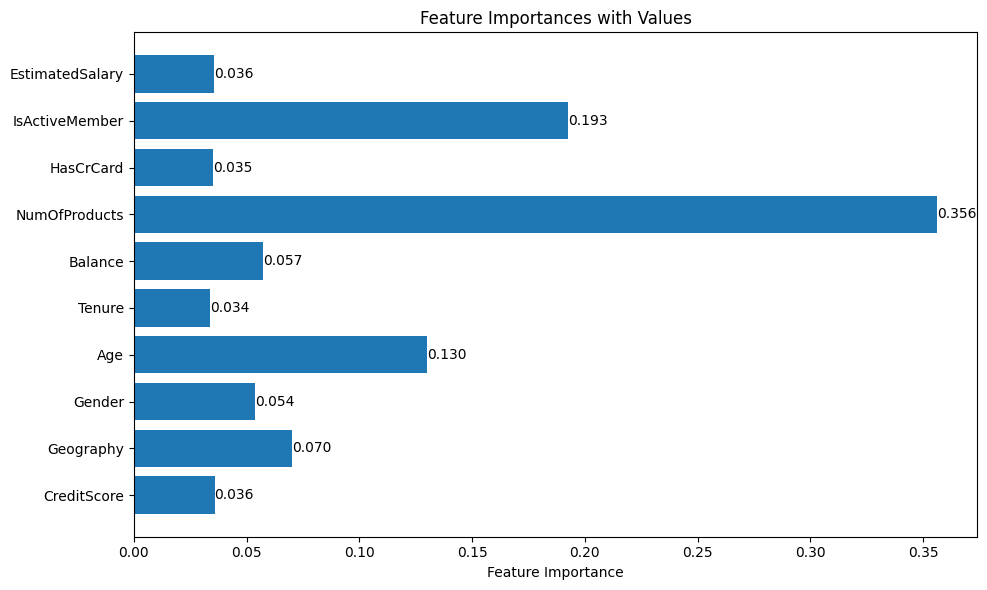

In [24]:
import matplotlib.pyplot as plt

feature_names = df.drop(columns=excluded_columns).columns
importances = model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importances with Values")
for i, v in enumerate(importances):
    plt.text(v, i, f"{v:.3f}", va='center')
plt.tight_layout()
plt.show()

In [20]:
df.drop(columns=excluded_columns).iloc[0:1, :]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.0,1,1,1,101348.88
